# 🏥 EDA Completo — Dataset Salud Hospitalaria
### Evaluación Parcial 1 — SCY1101 Programación para la Ciencia de Datos
**Autor:** Guillermo Cerda  
**Objetivo:** Análisis exploratorio exhaustivo para identificar todos los problemas de calidad de datos antes de construir el pipeline Kedro.

---
## ⚙️ Instrucciones de uso
1. Coloca este notebook en la carpeta `notebooks/` de tu proyecto Kedro.
2. Asegúrate de tener los 4 CSV en `data/01_raw/`.
3. Ejecuta todas las celdas en orden con **Kernel → Restart & Run All**.

---
## 📦 SECCIÓN 0 — Importaciones y configuración

In [1]:
!uv pip install "kedro==1.3.0" "kedro-viz" pandas numpy matplotlib seaborn scipy scikit-learn ipykernel jupyter jupyterlab"

Using Python 3.11.9 environment at: C:\Users\Guillermo\Desktop\Desk\U\ProgramacionParaLaCienciaDeDatos\Evaluacion_1\evaluacion_1_GuillermoCerda\.venv
Checked 11 packages in 37ms


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4)

# ── Rutas ──────────────────────────────────────────────────────────────────
# Ajusta RAW_PATH si ejecutas desde otro directorio
RAW_PATH = Path('../data/01_raw')
if not RAW_PATH.exists():
    RAW_PATH = Path('data/01_raw')   # fallback si se ejecuta desde la raíz

print('✅ Librerías cargadas correctamente')
print(f'📂 Ruta de datos: {RAW_PATH.resolve()}')

✅ Librerías cargadas correctamente
📂 Ruta de datos: C:\Users\Guillermo\Desktop\Desk\U\ProgramacionParaLaCienciaDeDatos\Evaluacion_1\evaluacion_1_GuillermoCerda\evaluacion-prueba-1-guillermocerda\data\01_raw


---
## 📥 SECCIÓN 1 — Carga de datos

In [3]:
# Se cargan todos los CSV como strings primero (dtype=str) para NO perder
# información en columnas con tipos mixtos (ej: '278878.0 aprox').
# El tipado correcto se analizará y realizará más adelante de forma controlada.

pacientes     = pd.read_csv(RAW_PATH / 'pacientes.csv',     dtype=str, encoding='utf-8')
consultas     = pd.read_csv(RAW_PATH / 'consultas.csv',     dtype=str, encoding='utf-8')
examenes      = pd.read_csv(RAW_PATH / 'examenes.csv',      dtype=str, encoding='utf-8')
medicamentos  = pd.read_csv(RAW_PATH / 'medicamentos.csv',  dtype=str, encoding='utf-8')

datasets = {
    'pacientes':    pacientes,
    'consultas':    consultas,
    'examenes':     examenes,
    'medicamentos': medicamentos,
}

for name, df in datasets.items():
    print(f'  ✅ {name:15s} → {df.shape[0]:>4} filas × {df.shape[1]:>2} columnas')

  ✅ pacientes       →  412 filas ×  8 columnas
  ✅ consultas       →  824 filas ×  8 columnas
  ✅ examenes        →  618 filas ×  8 columnas
  ✅ medicamentos    →  515 filas ×  7 columnas


---
## 🔍 SECCIÓN 2 — Inspección estructural básica
Revisamos shape, dtypes, primeras/últimas filas y estadísticas descriptivas.

In [4]:
def inspeccion_basica(df: pd.DataFrame, nombre: str) -> None:
    print('=' * 65)
    print(f'  📋 TABLA: {nombre.upper()}')
    print('=' * 65)
    print(f'  Forma        : {df.shape[0]} filas × {df.shape[1]} columnas')
    print(f'  Memoria aprox: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
    print()
    print('── Tipos de datos ──────────────────────────────────────────')
    print(df.dtypes.to_string())
    print()

for name, df in datasets.items():
    inspeccion_basica(df, name)

  📋 TABLA: PACIENTES
  Forma        : 412 filas × 8 columnas
  Memoria aprox: 58.8 KB

── Tipos de datos ──────────────────────────────────────────
id_paciente         str
nombre              str
rut                 str
fecha_nacimiento    str
genero              str
prevision           str
comuna              str
telefono            str

  📋 TABLA: CONSULTAS
  Forma        : 824 filas × 8 columnas
  Memoria aprox: 100.8 KB

── Tipos de datos ──────────────────────────────────────────
id_consulta               str
id_paciente               str
fecha                     str
id_medico                 str
especialidad              str
diagnostico_principal     str
diagnostico_secundario    str
costo                     str

  📋 TABLA: EXAMENES
  Forma        : 618 filas × 8 columnas
  Memoria aprox: 70.8 KB

── Tipos de datos ──────────────────────────────────────────
id_examen           str
id_consulta         str
tipo_examen         str
fecha_examen        str
resultado           str
va

In [5]:
# ── Primeras 5 filas de cada tabla ────────────────────────────────────────
for name, df in datasets.items():
    sep = "=" * 30
    print(f'\n{sep} {name.upper()} — head(5) {sep}')
    display(df.head())



============================== PACIENTES — head(5) ==============================


,id_paciente,nombre,rut,fecha_nacimiento,genero,prevision,comuna,telefono
0,1.0,Natalia García Pérez,5270111-3,01/01/1940,Femenino,Particular,Talca,+56992777798
1,2.0,Emilio Bravo González,10391529-5,1940-03-05,Masculino,Fonasa B,Chillán,+56978079231
2,3.0,Martín García Pérez,5370917-1,NaN,Femenino,Fonasa D,Coquimbo,NaN
3,4.0,Martín Rodríguez Rojas,NaN,1940-07-13,Masculino,Fonasa A,Talca,+56985900715
4,5.0,Nicolás Flores Rojas,17733334-5,1940-09-16,Femenino,Fonasa C,Talcahuano,NaN



============================== CONSULTAS — head(5) ==============================


,id_consulta,id_paciente,fecha,id_medico,especialidad,diagnostico_principal,diagnostico_secundario,costo
0,1.0,223.0,01/01/2023,43.0,PEDIATRÍA,Fractura,Ninguno,315120.0
1,2.0,174.0,2023-01-01,4.0,pediatría,Infección respiratoria,NaN,401661.0
2,3.0,191.0,02/01/2023,42.0,Oftalmología,Diabetes,Depresión,367092.0
3,4.0,140.0,2023-01-03,1.0,Oftalmología,NaN,Obesidad,219153.0
4,5.0,297.0,NaN,34.0,NaN,Control preventivo,Ninguno,410456.0



============================== EXAMENES — head(5) ==============================


,id_examen,id_consulta,tipo_examen,fecha_examen,resultado,valor_referencia,unidad,laboratorio
0,1.0,535.0,TAC,2023-01-05,40.51,0-100,mg/dL,Lab Central
1,2.0,142.0,Orina Completa,06/01/2023,123.92,10-200,mg/dL,Lab Central
2,3.0,NaN,Electrocardiograma,07/01/2023,26.82,10-200,U/L,Lab Sur
3,NaN,440.0,Electrocardiograma,2023-01-08,34.13,10-200,mm/hr,Lab Externo
4,5.0,628.0,Orina Completa,09/01/2023,271.24,10-200,U/L,Lab Externo



============================== MEDICAMENTOS — head(5) ==============================


,id_prescripcion,id_consulta,medicamento,dosis,frecuencia,duracion_dias,costo_unitario
0,1.0,756.0,Omeprazol,100mg,Cada 12 hrs,80.0,21751.0
1,2.0,687.0,Amoxicilina,50mg,Cada 24 hrs,50.0,42881.0
2,3.0,508.0,Losartán,200mg,SOS,4.0,1903.0
3,4.0,601.0,Paracetamol,20mg,Cada 24 hrs,8.0,24738.0
4,5.0,20.0,Omeprazol,500mg,NaN,36.0,47645.0


In [6]:
# ── Últimas 5 filas (detecta problemas al final del archivo) ──────────────
for name, df in datasets.items():
    sep = "=" * 30
    print(f'\n{sep} {name.upper()} — tail(5) {sep}')
    display(df.tail())



============================== PACIENTES — tail(5) ==============================


,id_paciente,nombre,rut,fecha_nacimiento,genero,prevision,comuna,telefono
407,342.0,Antonia Díaz Valenzuela,18590463-0,04/09/2000,Femenino,Particular,Los Ángeles,+56995715276
408,NaN,Carolina Castro Morales,11744883-8,11/01/1972,MASCULINO,Isapre,Villarrica,+56931742665
409,321.0,Fernanda Zambrano Silva,9183609-2,1996-12-09,Masculino,Fonasa B,Concepción,+56921278771
410,283.0,Ana Gatica Figueroa,24248978-1,06/03/1990,Femenino,Fonasa A,Quilpué,+56973391224
411,391.0,NaN,9561901-1,2009-05-25,Femenino,Fonasa A,La Serena,+56984734631



============================== CONSULTAS — tail(5) ==============================


,id_consulta,id_paciente,fecha,id_medico,especialidad,diagnostico_principal,diagnostico_secundario,costo
819,219.0,28.0,19/07/2023,16.0,ginecología,Fractura,Hipertensión,184742.0
820,557.0,27.0,NaN,39.0,oftalmología,Migraña,Ansiedad,299945.0
821,63.0,99.0,26/02/2023,45.0,Traumatología,Dermatitis,Hipertensión,481935.0
822,350.0,154.0,15/11/2023,12.0,Pediatría,Dermatitis,Ansiedad,NaN
823,390.0,159.0,22/12/2023,14.0,NaN,Gastritis,Ansiedad,462897.0



============================== EXAMENES — tail(5) ==============================


,id_examen,id_consulta,tipo_examen,fecha_examen,resultado,valor_referencia,unidad,laboratorio
613,301.0,79.0,PCR,2024-01-06,100.52,0-100,mg/dL,Lab Norte
614,438.0,458.0,NaN,2024-06-21,272.35,0-100,mmol/L,Lab Norte
615,11.0,305.0,Ecografía,2023-01-17,172.41,0-100,U/L,Lab Central
616,103.0,494.0,Glicemia,09/05/2023,101.0,0-100,mg/dL,Lab Sur
617,486.0,178.0,TAC,2024-08-18,131.78,0-100,%,Lab Urgencia



============================== MEDICAMENTOS — tail(5) ==============================


,id_prescripcion,id_consulta,medicamento,dosis,frecuencia,duracion_dias,costo_unitario
510,407.0,53.0,NaN,500mg,Cada 6 hrs,5.0,49883.0
511,187.0,438.0,Metformina,200mg,Cada 24 hrs,55.0,6040.0
512,337.0,691.0,Paracetamol,20mg,Cada 24 hrs,17.0,12839.0
513,177.0,102.0,Ibuprofeno,1g,Cada 6 hrs,18.0,29222.0
514,439.0,709.0,Sertralina,1g,Cada 24 hrs,57.0,12703.0


---
## 🕳️ SECCIÓN 3 — Análisis de valores nulos (NaN / vacíos)


  🕳️  NULOS EN: PACIENTES


,NaN reales,Strings vacíos,Total nulos,% del total
fecha_nacimiento,24,0,24,5.83
telefono,23,0,23,5.58
prevision,22,0,22,5.34
nombre,21,0,21,5.10
comuna,20,0,20,4.85
id_paciente,20,0,20,4.85
genero,16,0,16,3.88
rut,13,0,13,3.16


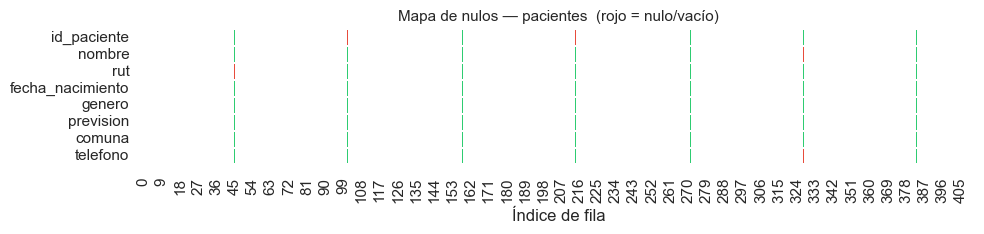


  🕳️  NULOS EN: CONSULTAS


,NaN reales,Strings vacíos,Total nulos,% del total
diagnostico_secundario,170,0,170,20.63
id_medico,50,0,50,6.07
id_consulta,44,0,44,5.34
diagnostico_principal,43,0,43,5.22
costo,39,0,39,4.73
fecha,39,0,39,4.73
especialidad,33,0,33,4.00
id_paciente,31,0,31,3.76


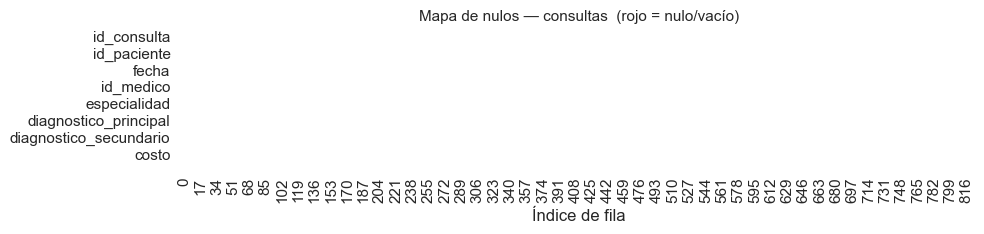


  🕳️  NULOS EN: EXAMENES


,NaN reales,Strings vacíos,Total nulos,% del total
id_consulta,43,0,43,6.96
laboratorio,36,0,36,5.83
unidad,33,0,33,5.34
fecha_examen,31,0,31,5.02
tipo_examen,28,0,28,4.53
valor_referencia,25,0,25,4.05
resultado,23,0,23,3.72
id_examen,18,0,18,2.91


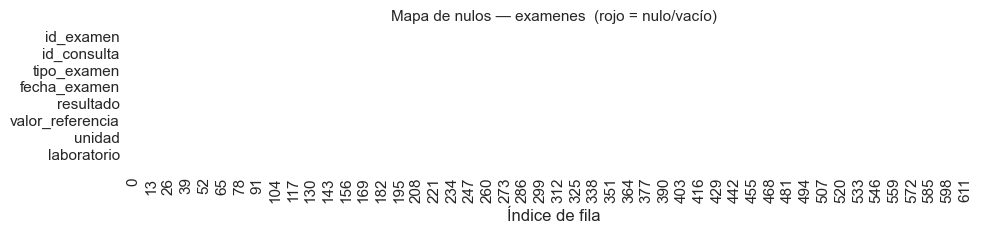


  🕳️  NULOS EN: MEDICAMENTOS


,NaN reales,Strings vacíos,Total nulos,% del total
duracion_dias,35,0,35,6.80
medicamento,33,0,33,6.41
frecuencia,29,0,29,5.63
id_consulta,26,0,26,5.05
costo_unitario,22,0,22,4.27
id_prescripcion,19,0,19,3.69
dosis,16,0,16,3.11


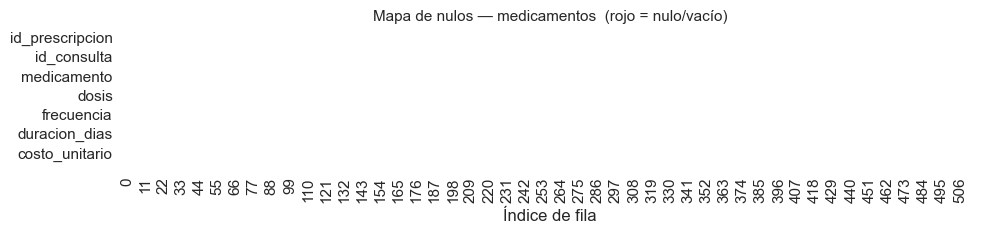

In [7]:
def analisis_nulos(df, nombre):
    """
    Detecta nulos reales (NaN) Y strings vacíos / solo espacios,
    que pandas no reconoce como NaN por defecto al cargar con dtype=str.
    """
    sep = "=" * 55
    nulos_reales = df.isnull().sum()
    vacios_str   = df.apply(lambda c: c.str.strip().eq('').sum() if c.dtype == object else 0)
    total_nulos  = nulos_reales + vacios_str
    pct          = (total_nulos / len(df) * 100).round(2)

    resumen = pd.DataFrame({
        'NaN reales':     nulos_reales,
        'Strings vacíos': vacios_str,
        'Total nulos':    total_nulos,
        '% del total':    pct,
    }).sort_values('Total nulos', ascending=False)

    print(f'\n{sep}')
    print(f'  🕳️  NULOS EN: {nombre.upper()}')
    print(sep)
    display(resumen[resumen['Total nulos'] > 0])

    if total_nulos.sum() > 0:
        fig, ax = plt.subplots(figsize=(10, 2.5))
        cols_con_nulos = total_nulos[total_nulos > 0].index.tolist()
        mask = df[cols_con_nulos].isnull() | df[cols_con_nulos].apply(
            lambda c: c.str.strip().eq('') if c.dtype == object else pd.Series(False, index=c.index)
        )
        sns.heatmap(mask.T, cbar=False, yticklabels=True,
                    cmap=['#2ecc71', '#e74c3c'], ax=ax, linewidths=0.1)
        ax.set_title(f'Mapa de nulos — {nombre}  (rojo = nulo/vacío)', fontsize=11)
        ax.set_xlabel('Índice de fila')
        plt.tight_layout()
        plt.show()
    return resumen

for name, df in datasets.items():
    analisis_nulos(df, name)


---
## 📋 SECCIÓN 4 — Análisis de duplicados

In [8]:
def analisis_duplicados(df, nombre, id_col=None):
    sep = "=" * 55
    print(f'\n{sep}')
    print(f'  📋 DUPLICADOS EN: {nombre.upper()}')
    print(sep)

    dup_filas = df.duplicated().sum()
    print(f'  Filas completamente duplicadas : {dup_filas} ({dup_filas/len(df)*100:.2f}%)')

    if id_col and id_col in df.columns:
        vals   = df[id_col].dropna()
        dup_id = vals.duplicated().sum()
        print(f'  IDs duplicados en "{id_col}"      : {dup_id} ({dup_id/len(df)*100:.2f}%)')
        if dup_id > 0:
            ids_dup = vals[vals.duplicated(keep=False)].unique()
            print(f'  IDs con duplicado               : {ids_dup[:10].tolist()} ...')
            display(df[df[id_col].isin(ids_dup)].head(6))

    if dup_filas == 0:
        print('  ✅ Sin duplicados de fila completa.')

analisis_duplicados(pacientes,    'pacientes',    'id_paciente')
analisis_duplicados(consultas,    'consultas',    'id_consulta')
analisis_duplicados(examenes,     'examenes',     'id_examen')
analisis_duplicados(medicamentos, 'medicamentos', 'id_prescripcion')



  📋 DUPLICADOS EN: PACIENTES
  Filas completamente duplicadas : 12 (2.91%)
  IDs duplicados en "id_paciente"      : 11 (2.67%)
  IDs con duplicado               : ['11.0', '94.0', '138.0', '189.0', '283.0', '321.0', '333.0', '342.0', '364.0', '391.0'] ...


,id_paciente,nombre,rut,fecha_nacimiento,genero,prevision,comuna,telefono
10,11.0,Joaquín Reyes Contreras,24532469-0,1941-10-11,Femenino,fonasa a,Osorno,+56968405557
93,94.0,Nicolás Rojas González,14353117-7,19/07/1956,No binario,Fonasa C,Rancagua,+56932015250
137,138.0,Sebastián Díaz González,19086135-7,1964-05-17,masculino,fonasa d,Rengo,+56941750868
188,189.0,Fernanda Hernández Vergara,11788292-0,1973-06-14,Femenino,Fonasa D,Puente Alto,+56967408518
282,283.0,Ana Gatica Figueroa,24248978-1,06/03/1990,Femenino,Fonasa A,Quilpué,+56973391224
320,321.0,Fernanda Zambrano Silva,9183609-2,1996-12-09,Masculino,Fonasa B,Concepción,+56921278771



  📋 DUPLICADOS EN: CONSULTAS
  Filas completamente duplicadas : 24 (2.91%)
  IDs duplicados en "id_consulta"      : 24 (2.91%)
  IDs con duplicado               : ['25.0', '63.0', '115.0', '213.0', '219.0', '260.0', '321.0', '350.0', '385.0', '390.0'] ...


,id_consulta,id_paciente,fecha,id_medico,especialidad,diagnostico_principal,diagnostico_secundario,costo
24,25.0,294.0,2023-01-22,21.0,Neurología,Control preventivo,Depresión,359213.0
62,63.0,99.0,26/02/2023,45.0,Traumatología,Dermatitis,Hipertensión,481935.0
114,115.0,316.0,NaN,38.0,Dermatología,Lumbalgia,NaN,199149.0
212,213.0,NaN,2023-07-13,45.0,Traumatología,Diabetes,Diabetes,$433333.0
218,219.0,28.0,19/07/2023,16.0,ginecología,Fractura,Hipertensión,184742.0
259,260.0,392.0,2023-08-25,17.0,Dermatología,NaN,Ansiedad,45134.0



  📋 DUPLICADOS EN: EXAMENES
  Filas completamente duplicadas : 18 (2.91%)
  IDs duplicados en "id_examen"      : 18 (2.91%)
  IDs con duplicado               : ['8.0', '11.0', '27.0', '28.0', '66.0', '103.0', '108.0', '119.0', '145.0', '159.0'] ...


,id_examen,id_consulta,tipo_examen,fecha_examen,resultado,valor_referencia,unidad,laboratorio
7,8.0,25.0,Ecografía,2023-01-13,41.76,10-200,mmol/L,Lab Norte
10,11.0,305.0,Ecografía,2023-01-17,172.41,0-100,U/L,Lab Central
26,27.0,540.0,Orina Completa,05/02/2023,45.27,0-100,mm/hr,Lab Norte
27,28.0,439.0,Orina Completa,2023-02-06,NaN,0-100,g/dL,Lab Externo
65,66.0,666.0,Radiografía,2023-03-25,194.71,0-100,U/L,NaN
102,103.0,494.0,Glicemia,09/05/2023,101.0,0-100,mg/dL,Lab Sur



  📋 DUPLICADOS EN: MEDICAMENTOS
  Filas completamente duplicadas : 15 (2.91%)
  IDs duplicados en "id_prescripcion"      : 15 (2.91%)
  IDs con duplicado               : ['29.0', '93.0', '110.0', '131.0', '177.0', '187.0', '191.0', '206.0', '289.0', '292.0'] ...


,id_prescripcion,id_consulta,medicamento,dosis,frecuencia,duracion_dias,costo_unitario
28,29.0,787.0,Paracetamol,20mg,NaN,5.0,42441.0
92,93.0,247.0,paracetamol,100mg,Cada 6 hrs,NaN,28726.0
109,110.0,351.0,Metformina,200mg,Cada 6 hrs,7.0,18835.0
130,131.0,680.0,PARACETAMOL,20mg,Cada 24 hrs,NaN,15322.0
176,177.0,102.0,Ibuprofeno,1g,Cada 6 hrs,18.0,29222.0
186,187.0,438.0,Metformina,200mg,Cada 24 hrs,55.0,6040.0


---
## 🔤 SECCIÓN 5 — Análisis de columnas categóricas
Detecta: case inconsistente, espacios, categorías raras, cardinalidad alta.


  🔤 COLUMNAS CATEGÓRICAS — PACIENTES

  📌 id_paciente
     Valores únicos (crudo)       : 381
     Valores únicos (normalizado) : 381
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
id_paciente
391.0    3
11.0     2
94.0     2
138.0    2
189.0    2
283.0    2
321.0    2
333.0    2
342.0    2
364.0    2

  📌 nombre
     Valores únicos (crudo)       : 380
     Valores únicos (normalizado) : 380
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
nombre
Joaquín Reyes Contreras       2
Nicolás Rojas González        2
Sebastián Díaz González       2
Carolina Martínez López       2
Carolina Castro Morales       2
Fernanda Hernández Vergara    2
Ana Gatica Figueroa           2
Fernanda Zambrano Silva       2
Ana Espinoza Bravo            2
Antonia Díaz Valenzuela       2

  📌 rut
     Valores únicos (crudo)       : 387
     Valores únicos (normaliz

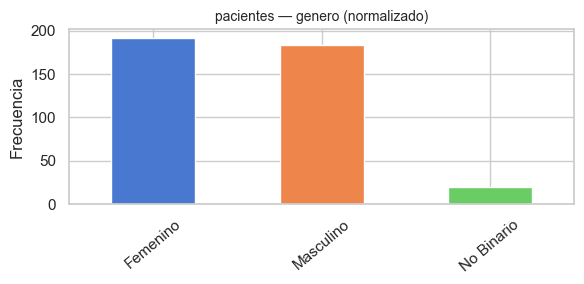


  📌 prevision
     Valores únicos (crudo)       : 24
     Valores únicos (normalizado) : 6
     ⚠️  Espacios al inicio/fin     : True
     ⚠️  Case inconsistente         : True
     Distribución normalizada:
       Isapre                              →   82 (19.9%)
       Fonasa C                            →   70 (17.0%)
       Particular                          →   67 (16.3%)
       Fonasa A                            →   63 (15.3%)
       Fonasa D                            →   58 (14.1%)
       Fonasa B                            →   50 (12.1%)


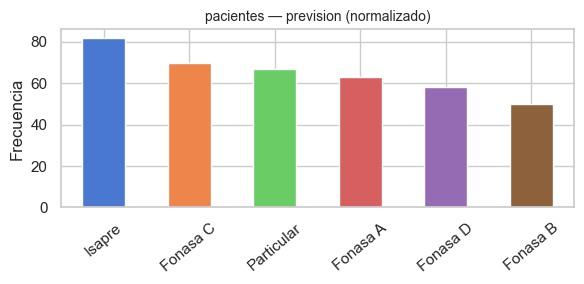


  📌 comuna
     Valores únicos (crudo)       : 30
     Valores únicos (normalizado) : 30
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     Distribución normalizada:
       Osorno                              →   21 (5.1%)
       Coquimbo                            →   20 (4.9%)
       Rengo                               →   20 (4.9%)
       Castro                              →   19 (4.6%)
       Viña Del Mar                        →   17 (4.1%)
       Talcahuano                          →   16 (3.9%)
       Rancagua                            →   16 (3.9%)
       Curicó                              →   15 (3.6%)
       Concepción                          →   15 (3.6%)
       Puerto Montt                        →   15 (3.6%)
       Maipú                               →   14 (3.4%)
       Talca                               →   13 (3.2%)
       Chillán                             →   13 (3.2%)
       Ovalle                              →   13 

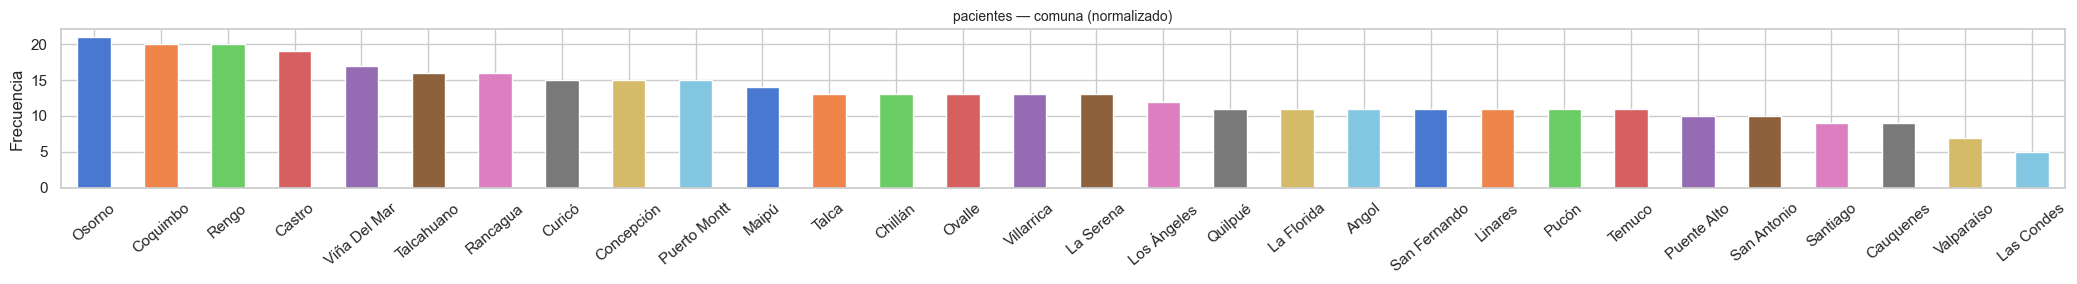


  📌 telefono
     Valores únicos (crudo)       : 377
     Valores únicos (normalizado) : 377
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
telefono
+56984734631    3
+56968405557    2
+56932015250    2
+56941750868    2
+56931742665    2
+56967408518    2
+56973391224    2
+56921278771    2
+56922448176    2
+56995715276    2

  🔤 COLUMNAS CATEGÓRICAS — CONSULTAS

  📌 id_consulta
     Valores únicos (crudo)       : 756
     Valores únicos (normalizado) : 756
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
id_consulta
25.0     2
63.0     2
115.0    2
213.0    2
219.0    2
260.0    2
321.0    2
350.0    2
385.0    2
390.0    2

  📌 id_paciente
     Valores únicos (crudo)       : 349
     Valores únicos (normalizado) : 349
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top

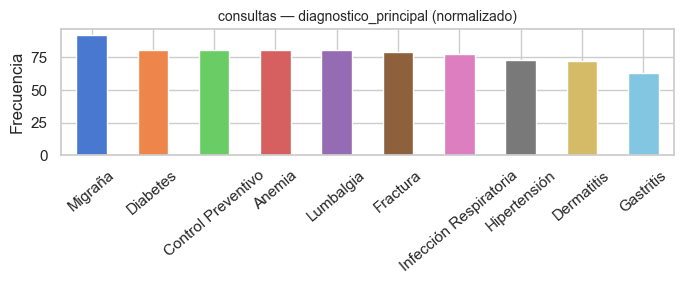


  📌 diagnostico_secundario
     Valores únicos (crudo)       : 6
     Valores únicos (normalizado) : 6
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     Distribución normalizada:
       Hipertensión                        →  118 (14.3%)
       Ansiedad                            →  118 (14.3%)
       Diabetes                            →  113 (13.7%)
       Depresión                           →  110 (13.3%)
       Obesidad                            →   99 (12.0%)
       Ninguno                             →   96 (11.7%)


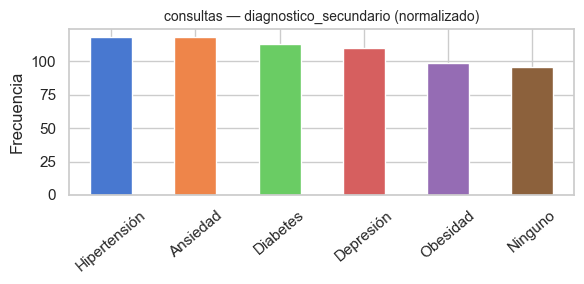


  📌 costo
     Valores únicos (crudo)       : 762
     Valores únicos (normalizado) : 762
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
costo
359213.0          2
481935.0          2
199149.0          2
$433333.0         2
184742.0          2
45134.0           2
216901.0 Aprox    2
97615.0           2
33258.0           2
462897.0          2

  🔤 COLUMNAS CATEGÓRICAS — EXAMENES

  📌 id_examen
     Valores únicos (crudo)       : 582
     Valores únicos (normalizado) : 582
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
id_examen
8.0      2
11.0     2
27.0     2
28.0     2
66.0     2
103.0    2
108.0    2
119.0    2
145.0    2
159.0    2

  📌 id_consulta
     Valores únicos (crudo)       : 386
     Valores únicos (normalizado) : 386
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad a

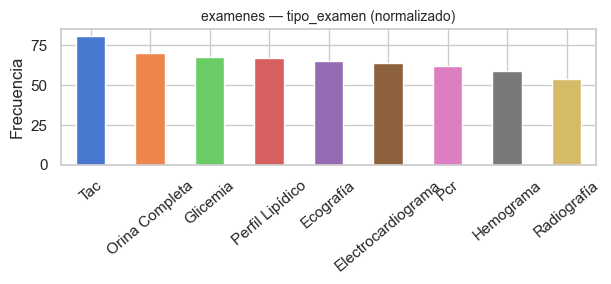


  📌 fecha_examen
     Valores únicos (crudo)       : 569
     Valores únicos (normalizado) : 569
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
fecha_examen
2023-01-13    2
2023-01-17    2
05/02/2023    2
2023-02-06    2
2023-03-25    2
09/05/2023    2
2023-05-15    2
29/05/2023    2
2023-06-29    2
2023-07-16    2

  📌 resultado
     Valores únicos (crudo)       : 574
     Valores únicos (normalizado) : 574
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
resultado
41.76     2
172.41    2
45.27     2
194.71    2
3.22      2
101.0     2
55.44     2
81.23     2
79.41     2
29.37     2

  📌 valor_referencia
     Valores únicos (crudo)       : 2
     Valores únicos (normalizado) : 2
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     Distribución normalizada:
       0-100                             

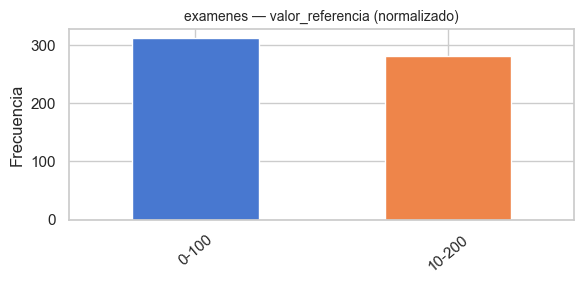


  📌 unidad
     Valores únicos (crudo)       : 6
     Valores únicos (normalizado) : 6
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     Distribución normalizada:
       U/L                                 →  103 (16.7%)
       Mg/Dl                               →  100 (16.2%)
       G/Dl                                →  100 (16.2%)
       %                                   →  100 (16.2%)
       Mmol/L                              →   94 (15.2%)
       Mm/Hr                               →   88 (14.2%)


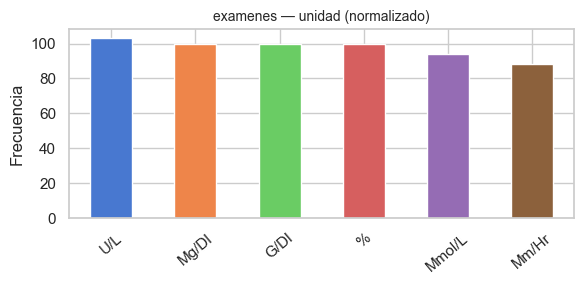


  📌 laboratorio
     Valores únicos (crudo)       : 5
     Valores únicos (normalizado) : 5
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     Distribución normalizada:
       Lab Sur                             →  125 (20.2%)
       Lab Externo                         →  122 (19.7%)
       Lab Central                         →  116 (18.8%)
       Lab Norte                           →  112 (18.1%)
       Lab Urgencia                        →  107 (17.3%)


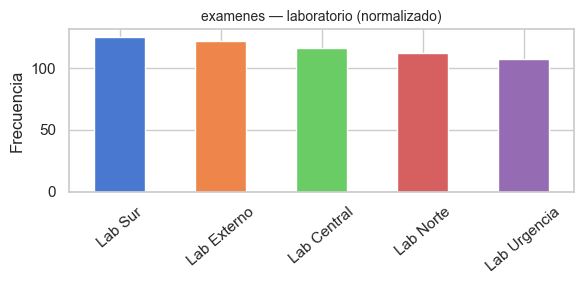


  🔤 COLUMNAS CATEGÓRICAS — MEDICAMENTOS

  📌 id_prescripcion
     Valores únicos (crudo)       : 481
     Valores únicos (normalizado) : 481
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
id_prescripcion
29.0     2
93.0     2
110.0    2
131.0    2
177.0    2
187.0    2
191.0    2
206.0    2
289.0    2
292.0    2

  📌 id_consulta
     Valores únicos (crudo)       : 350
     Valores únicos (normalizado) : 350
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
id_consulta
438.0    5
631.0    4
680.0    4
601.0    3
737.0    3
736.0    3
430.0    3
341.0    3
247.0    3
168.0    3

  📌 medicamento
     Valores únicos (crudo)       : 39
     Valores únicos (normalizado) : 10
     ⚠️  Espacios al inicio/fin     : True
     ⚠️  Case inconsistente         : True
     (Cardinalidad alta — top 10):
medicamento
Metformina       58
Amoxicilina      54

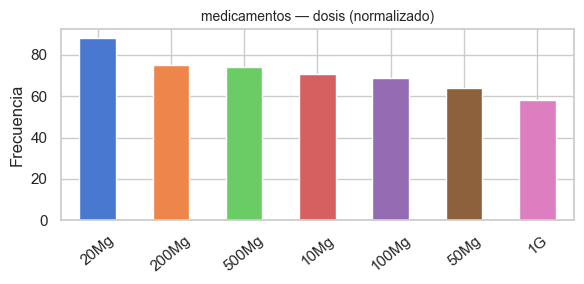


  📌 frecuencia
     Valores únicos (crudo)       : 5
     Valores únicos (normalizado) : 5
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     Distribución normalizada:
       Cada 24 Hrs                         →  107 (20.8%)
       Cada 12 Hrs                         →  100 (19.4%)
       Sos                                 →   99 (19.2%)
       Cada 8 Hrs                          →   98 (19.0%)
       Cada 6 Hrs                          →   82 (15.9%)


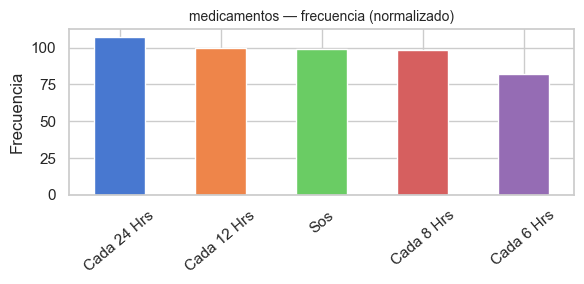


  📌 duracion_dias
     Valores únicos (crudo)       : 89
     Valores únicos (normalizado) : 89
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
duracion_dias
44.0    14
48.0    10
26.0    10
14.0    10
10.0     9
5.0      9
61.0     9
12.0     9
63.0     9
17.0     9

  📌 costo_unitario
     Valores únicos (crudo)       : 476
     Valores únicos (normalizado) : 476
     ⚠️  Espacios al inicio/fin     : False
     ⚠️  Case inconsistente         : False
     (Cardinalidad alta — top 10):
costo_unitario
42441.0    2
28093.0    2
1060.0     2
28726.0    2
18835.0    2
15322.0    2
29222.0    2
6040.0     2
38272.0    2
26108.0    2


In [9]:
def analisis_categoricas(df, nombre, umbral_cardinalidad=30):
    sep = "=" * 65
    print(f'\n{sep}')
    print(f'  🔤 COLUMNAS CATEGÓRICAS — {nombre.upper()}')
    print(sep)

    cat_cols = df.select_dtypes(include='object').columns

    for col in cat_cols:
        serie        = df[col].dropna()
        unique_raw   = serie.unique()
        unique_clean = serie.str.strip().str.title().unique()
        n_raw        = len(unique_raw)
        n_clean      = len(unique_clean)
        tiene_espacios = serie.str.startswith(' ').any() or serie.str.endswith(' ').any()
        tiene_case     = n_raw != n_clean

        print(f'\n  📌 {col}')
        print(f'     Valores únicos (crudo)       : {n_raw}')
        print(f'     Valores únicos (normalizado) : {n_clean}')
        print(f'     ⚠️  Espacios al inicio/fin     : {tiene_espacios}')
        print(f'     ⚠️  Case inconsistente         : {tiene_case}')

        if n_raw <= umbral_cardinalidad:
            vc = serie.str.strip().str.title().value_counts()
            print('     Distribución normalizada:')
            for val, cnt in vc.items():
                print(f'       {str(val):35s} → {cnt:>4} ({cnt/len(df)*100:.1f}%)')

            if 2 <= n_clean <= umbral_cardinalidad:
                fig, ax = plt.subplots(figsize=(max(6, n_clean * 0.7), 3))
                vc.plot(kind='bar', ax=ax, color=sns.color_palette('muted', n_clean))
                ax.set_title(f'{nombre} — {col} (normalizado)', fontsize=10)
                ax.set_xlabel('')
                ax.set_ylabel('Frecuencia')
                ax.tick_params(axis='x', rotation=40)
                plt.tight_layout()
                plt.show()
        else:
            print('     (Cardinalidad alta — top 10):')
            print(serie.str.strip().str.title().value_counts().head(10).to_string())

for name, df in datasets.items():
    analisis_categoricas(df, name)


---
## 🔢 SECCIÓN 6 — Análisis de columnas numéricas
Detecta: tipos mal asignados, rangos inválidos, outliers con Z-score e IQR.


  🔢 COLUMNAS NUMÉRICAS — PACIENTES

  📌 id_paciente
     Valores no parseables directamente: 0
     Min   : 1.00
     Max   : 399.00
     Media : 202.69
     Mediana:202.50
     Std   : 116.01
     Outliers Z-score (|z|>3.0) : 0
     Outliers IQR                  : 0


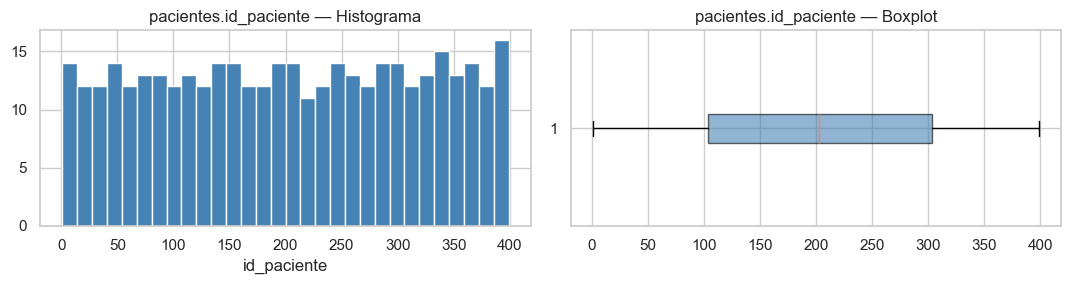


  🔢 COLUMNAS NUMÉRICAS — CONSULTAS

  📌 id_consulta
     Valores no parseables directamente: 0
     Min   : 1.00
     Max   : 800.00
     Media : 400.48
     Mediana:404.50
     Std   : 229.68
     Outliers Z-score (|z|>3.0) : 0
     Outliers IQR                  : 0


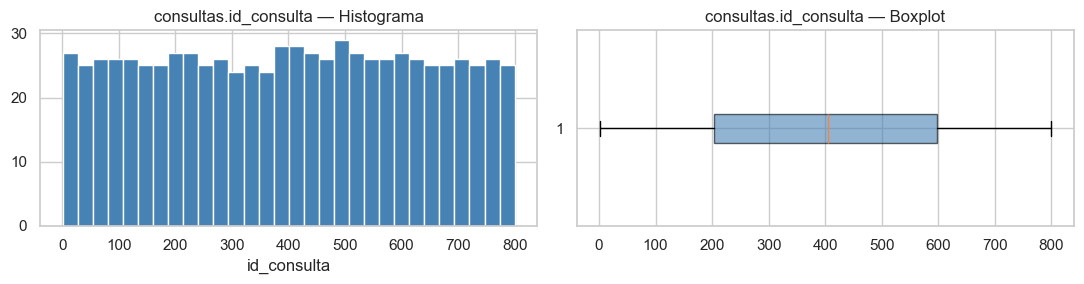


  📌 id_paciente
     Valores no parseables directamente: 0
     Min   : 1.00
     Max   : 400.00
     Media : 198.19
     Mediana:194.00
     Std   : 118.85
     Outliers Z-score (|z|>3.0) : 0
     Outliers IQR                  : 0


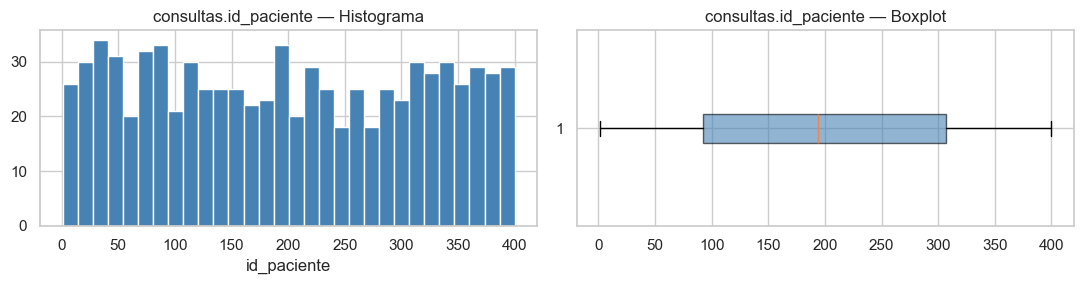


  📌 id_medico
     Valores no parseables directamente: 0
     Min   : 1.00
     Max   : 49.00
     Media : 24.55
     Mediana:24.00
     Std   : 14.11
     Outliers Z-score (|z|>3.0) : 0
     Outliers IQR                  : 0


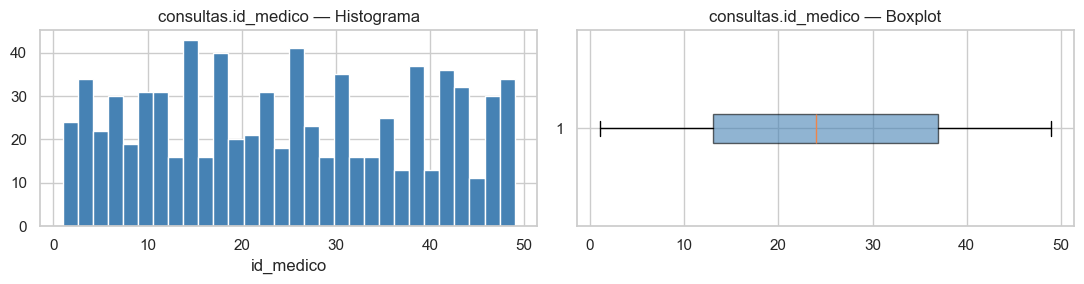


  📌 costo
     Valores no parseables directamente: 39
     Ejemplos problemáticos:
costo
$433333.0         2
216901.0 aprox    2
278878.0 aprox    1
$369248.0         1
$193994.0         1
     ➡️  Tras extracción forzada, NaN: 39
     Min   : 5010.00
     Max   : 45349900.00
     Media : 505645.31
     Mediana:272480.00
     Std   : 2728292.19
     Outliers Z-score (|z|>3.0) : 6
     Outliers IQR                  : 12


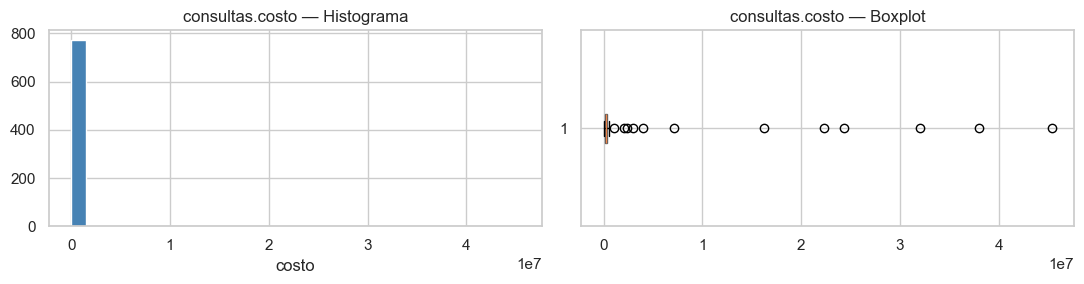


  🔢 COLUMNAS NUMÉRICAS — EXAMENES

  📌 id_examen
     Valores no parseables directamente: 0
     Min   : 1.00
     Max   : 600.00
     Media : 299.25
     Mediana:300.50
     Std   : 173.63
     Outliers Z-score (|z|>3.0) : 0
     Outliers IQR                  : 0


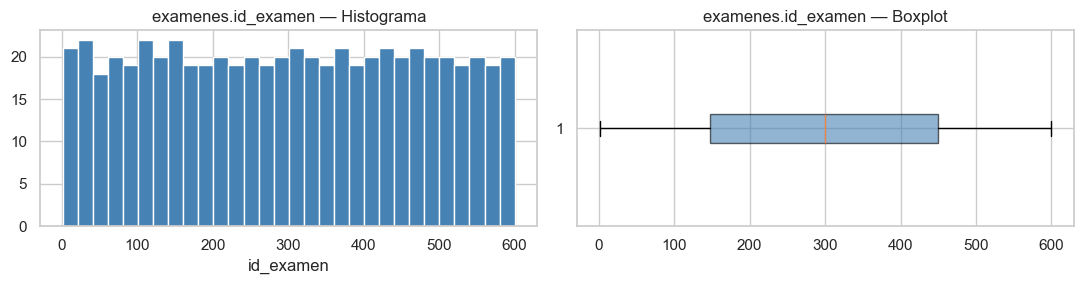


  📌 id_consulta
     Valores no parseables directamente: 0
     Min   : 1.00
     Max   : 800.00
     Media : 374.18
     Mediana:367.00
     Std   : 226.55
     Outliers Z-score (|z|>3.0) : 0
     Outliers IQR                  : 0


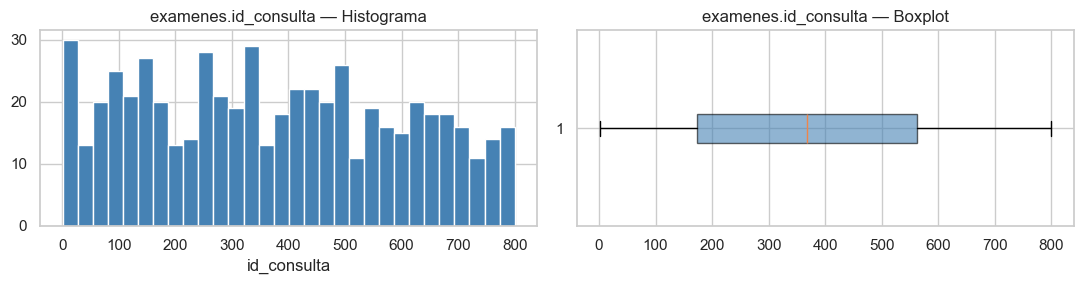


  📌 resultado
     Valores no parseables directamente: 0
     Min   : -1407.25
     Max   : 21052.00
     Media : 252.02
     Mediana:146.91
     Std   : 1234.71
     Outliers Z-score (|z|>3.0) : 4
     Outliers IQR                  : 12


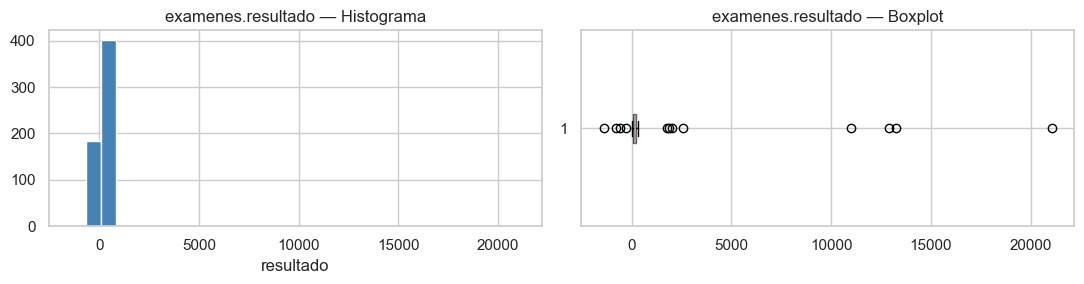


  🔢 COLUMNAS NUMÉRICAS — MEDICAMENTOS

  📌 id_prescripcion
     Valores no parseables directamente: 0
     Min   : 1.00
     Max   : 500.00
     Media : 248.75
     Mediana:249.50
     Std   : 143.93
     Outliers Z-score (|z|>3.0) : 0
     Outliers IQR                  : 0


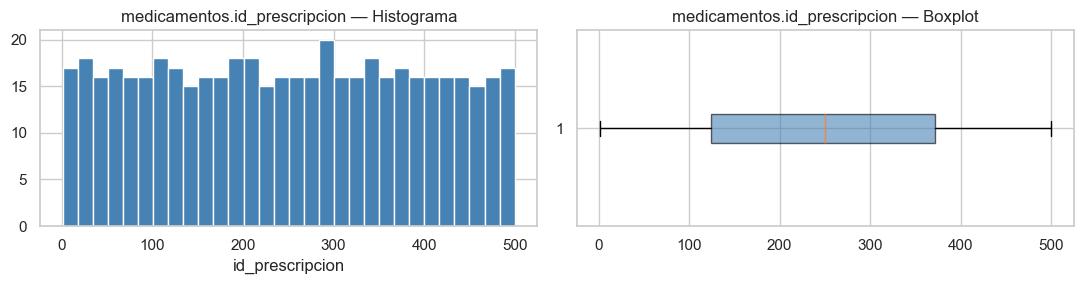


  📌 id_consulta
     Valores no parseables directamente: 0
     Min   : 1.00
     Max   : 794.00
     Media : 401.25
     Mediana:399.00
     Std   : 229.87
     Outliers Z-score (|z|>3.0) : 0
     Outliers IQR                  : 0


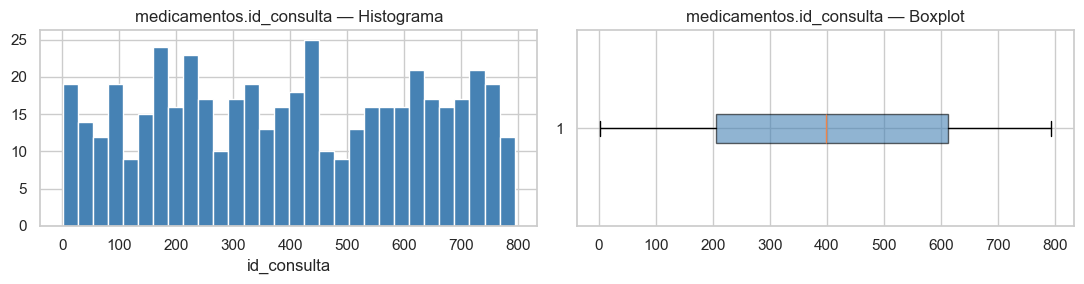


  📌 duracion_dias
     Valores no parseables directamente: 0
     Min   : 1.00
     Max   : 89.00
     Media : 44.69
     Mediana:44.00
     Std   : 26.14
     Outliers Z-score (|z|>3.0) : 0
     Outliers IQR                  : 0


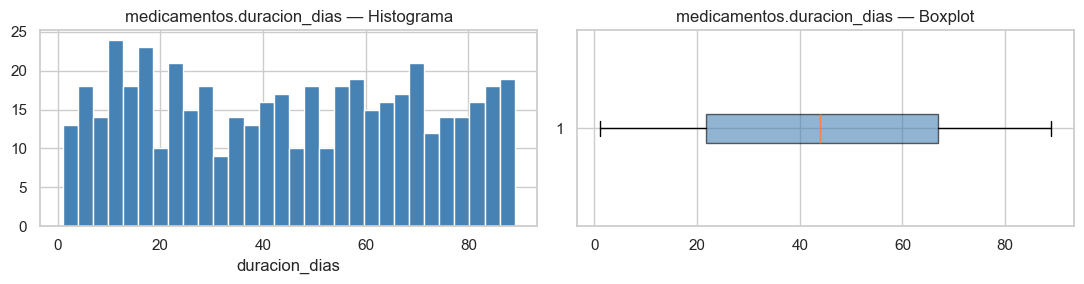


  📌 costo_unitario
     Valores no parseables directamente: 25
     Ejemplos problemáticos:
costo_unitario
~33556.0         1
~41463.0         1
13494.0 aprox    1
$22745.0         1
~16297.0         1
     ➡️  Tras extracción forzada, NaN: 22
     Min   : 512.00
     Max   : 49959.00
     Media : 25835.17
     Mediana:26269.00
     Std   : 14415.50
     Outliers Z-score (|z|>3.0) : 0
     Outliers IQR                  : 0


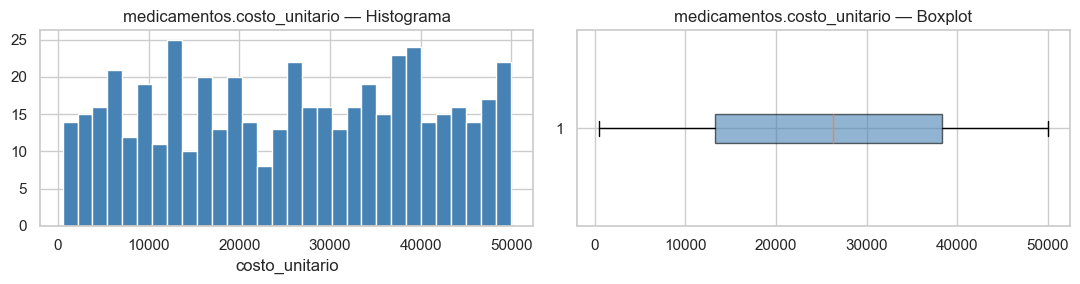

In [10]:
NUMERIC_TARGETS = {
    'pacientes':    ['id_paciente'],
    'consultas':    ['id_consulta', 'id_paciente', 'id_medico', 'costo'],
    'examenes':     ['id_examen', 'id_consulta', 'resultado'],
    'medicamentos': ['id_prescripcion', 'id_consulta', 'duracion_dias', 'costo_unitario'],
}

def intentar_numerico(serie):
    """Extrae el primer número flotante válido de cada celda string."""
    return serie.str.extract(r'([\d]+\.?[\d]*)', expand=False).astype(float)

def analisis_numericas(df, nombre, cols_objetivo, z_thresh=3.0):
    sep = "=" * 65
    print(f'\n{sep}')
    print(f'  🔢 COLUMNAS NUMÉRICAS — {nombre.upper()}')
    print(sep)

    for col in cols_objetivo:
        if col not in df.columns:
            continue

        serie_str    = df[col].copy()
        serie_num    = pd.to_numeric(serie_str, errors='coerce')
        no_parseable = serie_str.notna() & serie_num.isna()

        print(f'\n  📌 {col}')
        print(f'     Valores no parseables directamente: {no_parseable.sum()}')

        if no_parseable.sum() > 0:
            print('     Ejemplos problemáticos:')
            print(serie_str[no_parseable].value_counts().head(5).to_string())
            serie_num = intentar_numerico(serie_str.fillna(''))
            print(f'     ➡️  Tras extracción forzada, NaN: {serie_num.isna().sum()}')

        validos = serie_num.dropna()
        if len(validos) == 0:
            print('     ⛔ Sin valores numéricos válidos')
            continue

        print(f'     Min   : {validos.min():.2f}')
        print(f'     Max   : {validos.max():.2f}')
        print(f'     Media : {validos.mean():.2f}')
        print(f'     Mediana:{validos.median():.2f}')
        print(f'     Std   : {validos.std():.2f}')

        z_scores = np.abs(stats.zscore(validos))
        out_z    = (z_scores > z_thresh).sum()
        Q1, Q3   = validos.quantile(0.25), validos.quantile(0.75)
        IQR      = Q3 - Q1
        out_iqr  = ((validos < Q1 - 1.5*IQR) | (validos > Q3 + 1.5*IQR)).sum()

        print(f'     Outliers Z-score (|z|>{z_thresh}) : {out_z}')
        print(f'     Outliers IQR                  : {out_iqr}')

        fig, axes = plt.subplots(1, 2, figsize=(11, 3))
        axes[0].hist(validos, bins=30, color='steelblue', edgecolor='white')
        axes[0].set_title(f'{nombre}.{col} — Histograma')
        axes[0].set_xlabel(col)
        axes[1].boxplot(validos, vert=False, patch_artist=True,
                        boxprops=dict(facecolor='steelblue', alpha=0.6))
        axes[1].set_title(f'{nombre}.{col} — Boxplot')
        plt.tight_layout()
        plt.show()

for name, df in datasets.items():
    analisis_numericas(df, name, NUMERIC_TARGETS.get(name, []))


---
## 📅 SECCIÓN 7 — Análisis de columnas de fecha
Detecta: formatos mixtos, fechas futuras, fechas imposibles, rango temporal.


  📅 COLUMNAS DE FECHA — PACIENTES

  📌 fecha_nacimiento
     YYYY-MM-DD          : 188
     DD/MM/YYYY          : 200
     otros               : 0
     nulos               : 24
     Fechas inválidas tras parseo  : 188
     Rango válido      : 1940-01-01 → 2010-12-31
     Fechas futuras    : 0
     Fechas < 1900     : 0


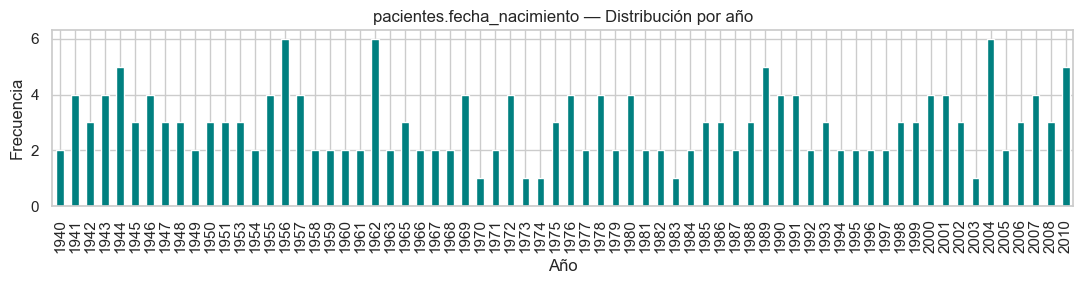


  📅 COLUMNAS DE FECHA — CONSULTAS

  📌 fecha
     YYYY-MM-DD          : 396
     DD/MM/YYYY          : 389
     otros               : 0
     nulos               : 39
     Fechas inválidas tras parseo  : 396
     Rango válido      : 2023-01-01 → 2024-12-22
     Fechas futuras    : 0
     Fechas < 1900     : 0


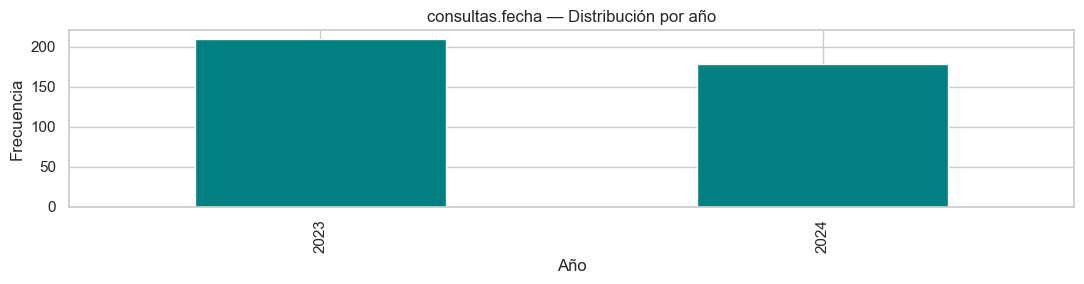


  📅 COLUMNAS DE FECHA — EXAMENES

  📌 fecha_examen
     YYYY-MM-DD          : 319
     DD/MM/YYYY          : 268
     otros               : 0
     nulos               : 31
     Fechas inválidas tras parseo  : 463
     Rango válido      : 2023-01-04 → 2025-03-01
     Fechas futuras    : 0
     Fechas < 1900     : 0


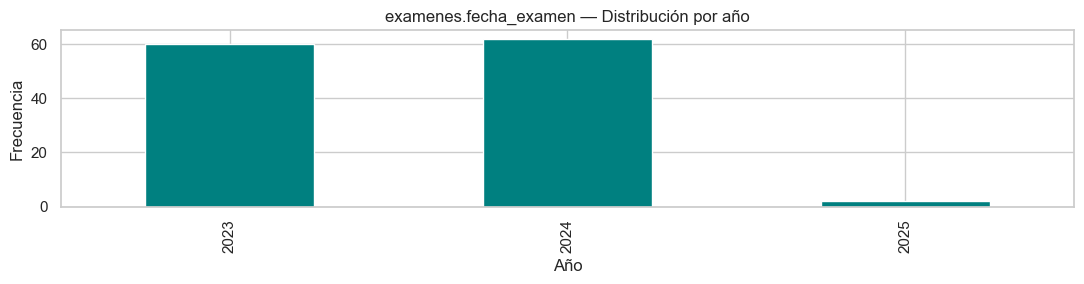

In [11]:
DATE_COLS = {
    'pacientes':    ['fecha_nacimiento'],
    'consultas':    ['fecha'],
    'examenes':     ['fecha_examen'],
    'medicamentos': [],
}

def detectar_formato_fecha(serie):
    """Clasifica cada valor según su formato de fecha aparente."""
    conteos = {'YYYY-MM-DD': 0, 'DD/MM/YYYY': 0, 'otros': 0, 'nulos': 0}
    for v in serie:
        if pd.isna(v) or str(v).strip() == '':
            conteos['nulos'] += 1
        elif re.match(r'^\d{4}-\d{2}-\d{2}$', str(v).strip()):
            conteos['YYYY-MM-DD'] += 1
        elif re.match(r'^\d{2}/\d{2}/\d{4}$', str(v).strip()):
            conteos['DD/MM/YYYY'] += 1
        else:
            conteos['otros'] += 1
    return conteos

def analisis_fechas(df, nombre, cols_fecha):
    if not cols_fecha:
        return
    sep = "=" * 65
    print(f'\n{sep}')
    print(f'  📅 COLUMNAS DE FECHA — {nombre.upper()}')
    print(sep)

    for col in cols_fecha:
        if col not in df.columns:
            continue
        print(f'\n  📌 {col}')
        formatos = detectar_formato_fecha(df[col])
        for fmt, cnt in formatos.items():
            print(f'     {fmt:20s}: {cnt}')

        fechas      = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
        n_invalidas = fechas.isna().sum() - df[col].isna().sum()
        print(f'     Fechas inválidas tras parseo  : {max(n_invalidas, 0)}')

        validas = fechas.dropna()
        if len(validas) == 0:
            continue

        hoy          = pd.Timestamp.today()
        futuras      = (validas > hoy).sum()
        muy_antiguas = (validas < pd.Timestamp('1900-01-01')).sum()

        print(f'     Rango válido      : {validas.min().date()} → {validas.max().date()}')
        print(f'     Fechas futuras    : {futuras}')
        print(f'     Fechas < 1900     : {muy_antiguas}')

        fig, ax = plt.subplots(figsize=(11, 3))
        validas.dt.year.value_counts().sort_index().plot(kind='bar', ax=ax, color='teal')
        ax.set_title(f'{nombre}.{col} — Distribución por año')
        ax.set_xlabel('Año')
        ax.set_ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

for name, df in datasets.items():
    analisis_fechas(df, name, DATE_COLS.get(name, []))


---
## 🔑 SECCIÓN 8 — Integridad referencial entre tablas
Verifica que las claves foráneas existan en la tabla padre.

In [12]:
def check_integridad_referencial(df_hijo, col_fk, df_padre, col_pk, nombre_rel):
    """
    Verifica que todos los valores de col_fk en df_hijo existan en col_pk de df_padre.
    """
    fk_vals   = pd.to_numeric(df_hijo[col_fk].dropna(), errors='coerce').dropna()
    pk_vals   = pd.to_numeric(df_padre[col_pk].dropna(), errors='coerce').dropna()
    huerfanos = fk_vals[~fk_vals.isin(pk_vals)]

    print(f'  🔗 {nombre_rel}')
    print(f'     FK no encontradas en padre: {len(huerfanos)} de {len(fk_vals)} '
          f'({len(huerfanos)/max(len(fk_vals),1)*100:.1f}%)')
    if len(huerfanos) > 0:
        print(f'     Ejemplos: {sorted(huerfanos.unique())[:8]}')
    print()

sep = "=" * 65
print('\n' + sep)
print('  🔑 INTEGRIDAD REFERENCIAL')
print(sep)
check_integridad_referencial(consultas,    'id_paciente', pacientes,  'id_paciente', 'consultas.id_paciente → pacientes.id_paciente')
check_integridad_referencial(examenes,     'id_consulta', consultas,  'id_consulta', 'examenes.id_consulta  → consultas.id_consulta')
check_integridad_referencial(medicamentos, 'id_consulta', consultas,  'id_consulta', 'medicamentos.id_consulta → consultas.id_consulta')



  🔑 INTEGRIDAD REFERENCIAL
  🔗 consultas.id_paciente → pacientes.id_paciente
     FK no encontradas en padre: 33 de 793 (4.2%)
     Ejemplos: [np.float64(9.0), np.float64(16.0), np.float64(38.0), np.float64(65.0), np.float64(102.0), np.float64(125.0), np.float64(172.0), np.float64(181.0)]

  🔗 examenes.id_consulta  → consultas.id_consulta
     FK no encontradas en padre: 26 de 575 (4.5%)
     Ejemplos: [np.float64(15.0), np.float64(43.0), np.float64(114.0), np.float64(122.0), np.float64(160.0), np.float64(170.0), np.float64(176.0), np.float64(247.0)]

  🔗 medicamentos.id_consulta → consultas.id_consulta
     FK no encontradas en padre: 24 de 489 (4.9%)
     Ejemplos: [np.float64(41.0), np.float64(89.0), np.float64(247.0), np.float64(262.0), np.float64(300.0), np.float64(349.0), np.float64(365.0), np.float64(370.0)]



---
## 🏷️ SECCIÓN 9 — Detección de tipos mal asignados
Identifica columnas que deberían ser de otro tipo: ID como float→int, numérico→categórico, etc.

In [13]:
def detectar_tipos_incorrectos(df, nombre):
    sep = "=" * 65
    print(f'\n{sep}')
    print(f'  🏷️  DETECCIÓN DE TIPOS — {nombre.upper()}')
    print(sep)

    for col in df.columns:
        serie = df[col].dropna()
        if len(serie) == 0:
            continue

        tipo_actual = df[col].dtype
        sugerencias = []

        if tipo_actual == object:
            num_conv = pd.to_numeric(serie, errors='coerce')
            pct_num  = num_conv.notna().mean()
            if pct_num >= 0.90:
                if num_conv.dropna().apply(float.is_integer).all():
                    sugerencias.append('⚠️  Parece INT (IDs o conteos)')
                else:
                    sugerencias.append('⚠️  Parece FLOAT (costos, resultados)')
                if pct_num < 1.0:
                    n_no     = int((1 - pct_num) * len(serie))
                    ejemplos = serie[num_conv.isna()].value_counts().head(3).index.tolist()
                    sugerencias.append(f'   → {n_no} valores no convertibles: {ejemplos}')

            fecha_conv = pd.to_datetime(serie, dayfirst=True, errors='coerce')
            if fecha_conv.notna().mean() >= 0.85 and pct_num < 0.9:
                sugerencias.append('⚠️  Parece DATETIME')

            n_uniq = serie.str.strip().str.title().nunique()
            if n_uniq <= 20 and len(serie) > 30:
                sugerencias.append(f'✅ Baja cardinalidad ({n_uniq} valores) → considerar CATEGORY')

            vals_lower = serie.str.strip().str.lower().unique()
            bool_sets  = [{'true','false'}, {'si','no'}, {'sí','no'},
                          {'1','0'}, {'yes','no'}, {'activo','inactivo'}]
            if any(set(vals_lower) <= bs for bs in bool_sets):
                sugerencias.append('⚠️  Parece BOOLEANA')

        if tipo_actual in [np.float64, float]:
            validos = pd.to_numeric(serie, errors='coerce').dropna()
            if len(validos) > 0 and validos.apply(float.is_integer).all():
                sugerencias.append('⚠️  float con todos .0 → debería ser INT (o ID string)')

        if sugerencias:
            print(f'\n  📌 {col!r:30s} (actual: {tipo_actual})')
            for s in sugerencias:
                print(f'     {s}')
        else:
            print(f'  ✅ {col!r:30s} (actual: {tipo_actual}) — tipo parece correcto')

for name, df in datasets.items():
    detectar_tipos_incorrectos(df, name)



  🏷️  DETECCIÓN DE TIPOS — PACIENTES
  ✅ 'id_paciente'                  (actual: str) — tipo parece correcto
  ✅ 'nombre'                       (actual: str) — tipo parece correcto
  ✅ 'rut'                          (actual: str) — tipo parece correcto
  ✅ 'fecha_nacimiento'             (actual: str) — tipo parece correcto
  ✅ 'genero'                       (actual: str) — tipo parece correcto
  ✅ 'prevision'                    (actual: str) — tipo parece correcto
  ✅ 'comuna'                       (actual: str) — tipo parece correcto
  ✅ 'telefono'                     (actual: str) — tipo parece correcto

  🏷️  DETECCIÓN DE TIPOS — CONSULTAS
  ✅ 'id_consulta'                  (actual: str) — tipo parece correcto
  ✅ 'id_paciente'                  (actual: str) — tipo parece correcto
  ✅ 'fecha'                        (actual: str) — tipo parece correcto
  ✅ 'id_medico'                    (actual: str) — tipo parece correcto
  ✅ 'especialidad'                 (actual: str) — tipo pare

---
## 🧹 SECCIÓN 10 — Análisis de strings: espacios, case, caracteres especiales

In [14]:
def analisis_strings(df, nombre):
    sep = "=" * 65
    print(f'\n{sep}')
    print(f'  🧹 CALIDAD DE STRINGS — {nombre.upper()}')
    print(sep)

    str_cols = df.select_dtypes(include='object').columns
    for col in str_cols:
        serie = df[col].dropna()
        if len(serie) == 0:
            continue

        espacios_inicio = serie.str.startswith(' ').sum()
        espacios_fin    = serie.str.endswith(' ').sum()
        espacios_dobles = serie.str.contains(r'  +').sum()
        todo_upper      = serie.str.isupper().sum()
        todo_lower      = serie.str.islower().sum()
        chars_raros     = serie.str.contains(r'[^\w\s\-\./,áéíóúñÁÉÍÓÚÑ+()]',
                                              regex=True).sum()

        problemas = []
        if espacios_inicio: problemas.append(f'espacios al inicio: {espacios_inicio}')
        if espacios_fin:    problemas.append(f'espacios al final: {espacios_fin}')
        if espacios_dobles: problemas.append(f'espacios dobles internos: {espacios_dobles}')
        if todo_upper > 0 and todo_upper < len(serie):
            problemas.append(f'case mixto — UPPER: {todo_upper}, lower: {todo_lower}')
        if chars_raros:     problemas.append(f'caracteres especiales: {chars_raros}')

        if problemas:
            print(f'\n  ⚠️  {col}')
            for p in problemas:
                print(f'     → {p}')
            mask = (serie.str.startswith(' ') | serie.str.endswith(' ') | serie.str.isupper())
            print(f'     Ejemplos: {serie[mask].head(5).tolist()}')
        else:
            print(f'  ✅ {col} — sin problemas de formato')

for name, df in datasets.items():
    analisis_strings(df, name)



  🧹 CALIDAD DE STRINGS — PACIENTES
  ✅ id_paciente — sin problemas de formato
  ✅ nombre — sin problemas de formato
  ✅ rut — sin problemas de formato
  ✅ fecha_nacimiento — sin problemas de formato

  ⚠️  genero
     → espacios al inicio: 43
     → espacios al final: 43
     → espacios dobles internos: 43
     → case mixto — UPPER: 38, lower: 21
     Ejemplos: ['FEMENINO', '  Femenino  ', '  Femenino  ', 'FEMENINO', 'FEMENINO']

  ⚠️  prevision
     → espacios al inicio: 44
     → espacios al final: 44
     → espacios dobles internos: 44
     → case mixto — UPPER: 36, lower: 26
     Ejemplos: ['  Fonasa A  ', '  Fonasa D  ', '  Fonasa C  ', '  Fonasa C  ', '  Fonasa B  ']
  ✅ comuna — sin problemas de formato
  ✅ telefono — sin problemas de formato

  🧹 CALIDAD DE STRINGS — CONSULTAS
  ✅ id_consulta — sin problemas de formato
  ✅ id_paciente — sin problemas de formato
  ✅ fecha — sin problemas de formato
  ✅ id_medico — sin problemas de formato

  ⚠️  especialidad
     → espacios al 

---
## 📏 SECCIÓN 11 — Validación de rangos de negocio
Valores que son válidos numéricamente pero imposibles en el contexto médico.


  📏 VALIDACIÓN DE REGLAS DE NEGOCIO

  👤 Edades (calculadas desde fecha_nacimiento):
     Rango     : 15.3 – 86.3 años
     Media     : 50.9 años
     < 0 años  : 0 ← fecha_nacimiento futura (error)
     > 120 años: 0 ← probablemente error
     NaT       : 212 ← fechas no parseables


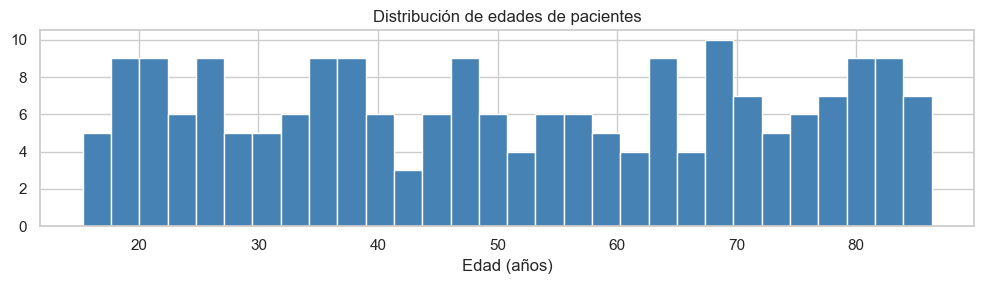


  💰 Costos de consultas:
     Rango  : $5,010 – $45,349,900
     <= 0   : 0 ← costos no positivos (error)
     NaN    : 39 ← no convertibles

  💊 Costos unitarios de medicamentos:
     Rango  : $512 – $49,959
     <= 0   : 0
     NaN    : 47

  📅 Duración de tratamientos (días):
     Rango  : 1 – 89 días
     <= 0   : 0
     > 365  : 0 ← tratamientos > 1 año (posibles outliers)

  🔬 Resultados de exámenes:
     Rango  : -1407.25 – 21052.00
     < 0    : 4 ← resultados negativos (posible error)
     NaN    : 23


In [15]:
print('\n' + '='*65)
print('  📏 VALIDACIÓN DE REGLAS DE NEGOCIO')
print('='*65)

# ── 1. Edades (derivadas de fecha_nacimiento) ─────────────────────────────
fechas_nac = pd.to_datetime(pacientes['fecha_nacimiento'], dayfirst=True, errors='coerce')
hoy = pd.Timestamp.today()
edades = ((hoy - fechas_nac).dt.days / 365.25).round(1)
print(f'\n  👤 Edades (calculadas desde fecha_nacimiento):')
print(f'     Rango     : {edades.min():.1f} – {edades.max():.1f} años')
print(f'     Media     : {edades.mean():.1f} años')
print(f'     < 0 años  : {(edades < 0).sum()} ← fecha_nacimiento futura (error)')
print(f'     > 120 años: {(edades > 120).sum()} ← probablemente error')
print(f'     NaT       : {edades.isna().sum()} ← fechas no parseables')

fig, ax = plt.subplots(figsize=(10, 3))
edades.dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribución de edades de pacientes')
ax.set_xlabel('Edad (años)')
plt.tight_layout()
plt.show()

# ── 2. Costos de consultas ────────────────────────────────────────────────
costos_c = pd.to_numeric(consultas['costo'].str.extract(r'([\d]+\.?[\d]*)')[0], errors='coerce')
print(f'\n  💰 Costos de consultas:')
print(f'     Rango  : ${costos_c.min():,.0f} – ${costos_c.max():,.0f}')
print(f'     <= 0   : {(costos_c <= 0).sum()} ← costos no positivos (error)')
print(f'     NaN    : {costos_c.isna().sum()} ← no convertibles')

# ── 3. Costos de medicamentos ─────────────────────────────────────────────
costos_m = pd.to_numeric(medicamentos['costo_unitario'], errors='coerce')
print(f'\n  💊 Costos unitarios de medicamentos:')
print(f'     Rango  : ${costos_m.min():,.0f} – ${costos_m.max():,.0f}')
print(f'     <= 0   : {(costos_m <= 0).sum()}')
print(f'     NaN    : {costos_m.isna().sum()}')

# ── 4. Duración de tratamientos ───────────────────────────────────────────
dur = pd.to_numeric(medicamentos['duracion_dias'], errors='coerce')
print(f'\n  📅 Duración de tratamientos (días):')
print(f'     Rango  : {dur.min():.0f} – {dur.max():.0f} días')
print(f'     <= 0   : {(dur <= 0).sum()}')
print(f'     > 365  : {(dur > 365).sum()} ← tratamientos > 1 año (posibles outliers)')

# ── 5. Resultados de exámenes ─────────────────────────────────────────────
res = pd.to_numeric(examenes['resultado'], errors='coerce')
print(f'\n  🔬 Resultados de exámenes:')
print(f'     Rango  : {res.min():.2f} – {res.max():.2f}')
print(f'     < 0    : {(res < 0).sum()} ← resultados negativos (posible error)')
print(f'     NaN    : {res.isna().sum()}')

---
## 🔗 SECCIÓN 12 — Análisis de correlaciones y relaciones entre variables

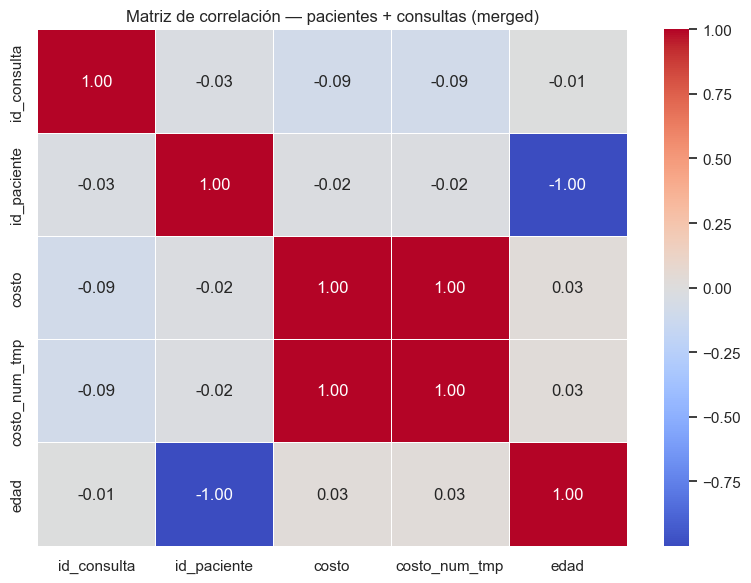

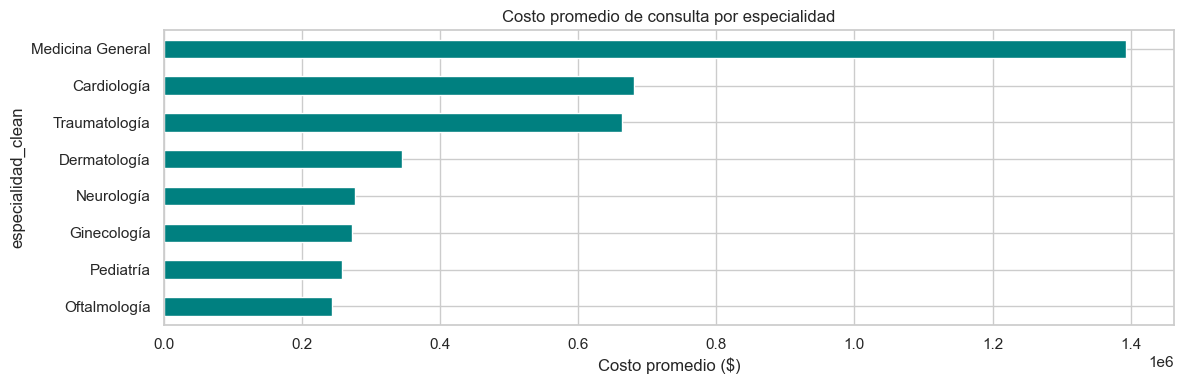

In [16]:
# Construimos un DataFrame integrado temporal solo para correlaciones
p_tmp = pacientes.copy()
c_tmp = consultas.copy()
m_tmp = medicamentos.copy()

# Extraer costo ANTES de convertir a numérico (aún es string aquí)
c_tmp['costo_num_tmp'] = pd.to_numeric(
    c_tmp['costo'].str.extract(r'([\d]+\.?[\d]*)')[0], errors='coerce')

# Normalizar IDs a float
for col in ['id_paciente']:
    p_tmp[col] = pd.to_numeric(p_tmp[col], errors='coerce')
    c_tmp[col] = pd.to_numeric(c_tmp[col], errors='coerce')

c_tmp['id_consulta']    = pd.to_numeric(c_tmp['id_consulta'],    errors='coerce')
m_tmp['id_consulta']    = pd.to_numeric(m_tmp['id_consulta'],    errors='coerce')
c_tmp['costo']          = c_tmp['costo_num_tmp']
m_tmp['costo_unitario'] = pd.to_numeric(m_tmp['costo_unitario'], errors='coerce')
m_tmp['duracion_dias']  = pd.to_numeric(m_tmp['duracion_dias'],  errors='coerce')

# Merge pacientes + consultas
merged = c_tmp.merge(p_tmp[['id_paciente', 'genero', 'prevision', 'fecha_nacimiento']],
                     on='id_paciente', how='left')

# Edad
merged['edad'] = ((pd.Timestamp.today() -
                   pd.to_datetime(merged['fecha_nacimiento'], dayfirst=True, errors='coerce')
                  ).dt.days / 365.25).round(1)

num_cols = merged.select_dtypes(include='number').columns.tolist()
if len(num_cols) >= 2:
    corr = merged[num_cols].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5)
    ax.set_title('Matriz de correlación — pacientes + consultas (merged)')
    plt.tight_layout()
    plt.show()

# Costo de consulta por especialidad
costo_esp = c_tmp.copy()
costo_esp['especialidad_clean'] = costo_esp['especialidad'].str.strip().str.title()

fig, ax = plt.subplots(figsize=(12, 4))
costo_esp.groupby('especialidad_clean')['costo_num_tmp'].mean().sort_values().plot(
    kind='barh', ax=ax, color='teal')
ax.set_title('Costo promedio de consulta por especialidad')
ax.set_xlabel('Costo promedio ($)')
plt.tight_layout()
plt.show()

---
## 📊 SECCIÓN 13 — Resumen ejecutivo de problemas encontrados
Tabla consolidada de todos los issues detectados para informar las decisiones del pipeline.

In [17]:
resumen_issues = [
    # (tabla, columna, tipo_problema, descripcion, accion_sugerida)
    ('pacientes',    'fecha_nacimiento', 'Fecha mixta',       'Formatos DD/MM/YYYY y YYYY-MM-DD mezclados',              'pd.to_datetime(dayfirst=True, errors=coerce)'),
    ('pacientes',    'genero',           'Case + espacios',   'Valores en mayúsculas, minúsculas y con espacios',        'str.strip().str.title() → pd.Categorical'),
    ('pacientes',    'prevision',        'Case + espacios',   'Hasta 25 variantes del mismo valor',                      'str.strip().str.title() → pd.Categorical'),
    ('pacientes',    'telefono',         'Tipo incorrecto',   'Float en vez de string (pierda el +56)',                  'Convertir a str, formatear como +56XXXXXXXXX'),
    ('pacientes',    'id_paciente',      'Float → Int',       'IDs llegan como float64 (1.0, 2.0…)',                     'pd.to_numeric → Int64 nullable'),
    ('pacientes',    'genero',           'Valor nulo',        'Registros sin género asignado',                           'Imputar con moda o categoría "Desconocido"'),
    ('consultas',    'especialidad',     'Case + espacios',   'Mismas especialidades en múltiples formatos',             'str.strip().str.title() → pd.Categorical'),
    ('consultas',    'costo',            'Tipo mixto',        'Contiene texto ("aprox") junto con números',              'Extraer número con regex, NaN donde no sea posible'),
    ('consultas',    'diagnostico_*',    'Valor nulo',        'Diagnósticos vacíos (~5%)',                               'Imputar con "Sin diagnóstico" o eliminar'),
    ('consultas',    'id_consulta',      'Float → Int',       'IDs como float64',                                        'pd.to_numeric → Int64'),
    ('examenes',     'id_examen',        'Nulos + Float→Int', 'IDs faltantes y en float',                                'Eliminar filas sin id_examen; convertir a Int64'),
    ('examenes',     'id_consulta',      'FK nula',           'Exámenes sin consulta asociada',                          'Revisar integridad; eliminar huérfanos'),
    ('examenes',     'fecha_examen',     'Fecha mixta',       'Mismos formatos mixtos que fecha_nacimiento',             'pd.to_datetime(dayfirst=True)'),
    ('examenes',     'valor_referencia', 'Tipo texto',        'Rango como string "10-200" (no numérico directamente)',   'Separar en val_ref_min y val_ref_max numéricos'),
    ('medicamentos', 'medicamento',      'Espacios',          'Nombres con espacios al inicio/fin',                      'str.strip().str.title()'),
    ('medicamentos', 'dosis',            'Valor mixto',       'Número + unidad juntos ("100mg")',                        'Separar en dosis_valor (float) + dosis_unidad (str)'),
    ('medicamentos', 'costo_unitario',   'Nulos + tipo',      'Algunos NaN y llegó como string',                         'pd.to_numeric(errors=coerce); imputar con mediana'),
    ('medicamentos', 'id_consulta',      'Float → Int',       'IDs como float64',                                        'pd.to_numeric → Int64'),
]

df_resumen = pd.DataFrame(resumen_issues,
    columns=['Tabla', 'Columna', 'Tipo de problema', 'Descripción', 'Acción sugerida'])

print('\n📋 RESUMEN CONSOLIDADO DE PROBLEMAS DE CALIDAD DE DATOS')
print(f'   Total de issues identificados: {len(df_resumen)}')
print()
display(df_resumen)

# Guardar resumen como CSV para el informe técnico
out_path = Path('../data/08_reporting')
if not out_path.exists():
    out_path = Path('data/08_reporting')
out_path.mkdir(parents=True, exist_ok=True)
df_resumen.to_csv(out_path / 'resumen_issues_eda.csv', index=False, encoding='utf-8')
print(f'\n✅ Resumen guardado en: {out_path / "resumen_issues_eda.csv"}')


📋 RESUMEN CONSOLIDADO DE PROBLEMAS DE CALIDAD DE DATOS
   Total de issues identificados: 18



,Tabla,Columna,Tipo de problema,Descripción,Acción sugerida
0,pacientes,fecha_nacimiento,Fecha mixta,Formatos DD/MM/YYYY y YYYY-MM-DD mezclados,"pd.to_datetime(dayfirst=True, errors=coerce)"
1,pacientes,genero,Case + espacios,"Valores en mayúsculas, minúsculas y con espacios",str.strip().str.title() → pd.Categorical
2,pacientes,prevision,Case + espacios,Hasta 25 variantes del mismo valor,str.strip().str.title() → pd.Categorical
3,pacientes,telefono,Tipo incorrecto,Float en vez de string (pierda el +56),"Convertir a str, formatear como +56XXXXXXXXX"
4,pacientes,id_paciente,Float → Int,"IDs llegan como float64 (1.0, 2.0…)",pd.to_numeric → Int64 nullable
5,pacientes,genero,Valor nulo,Registros sin género asignado,"Imputar con moda o categoría ""Desconocido"""
6,consultas,especialidad,Case + espacios,Mismas especialidades en múltiples formatos,str.strip().str.title() → pd.Categorical
7,consultas,costo,Tipo mixto,"Contiene texto (""aprox"") junto con números","Extraer número con regex, NaN donde no sea pos..."
8,consultas,diagnostico_*,Valor nulo,Diagnósticos vacíos (~5%),"Imputar con ""Sin diagnóstico"" o eliminar"
9,consultas,id_consulta,Float → Int,IDs como float64,pd.to_numeric → Int64



✅ Resumen guardado en: ..\data\08_reporting\resumen_issues_eda.csv


---
## ✅ SECCIÓN 14 — Checklist final antes del pipeline
Confirmación rápida de qué está listo y qué necesita trabajo.

In [18]:
checklist = {
    'pacientes': {
        'Nulos detectados y cuantificados': True,
        'Duplicados revisados':             True,
        'Fechas con formato mixto':         True,
        'Categorías con case inconsistente':True,
        'IDs en float (deben ser Int)':     True,
        'Teléfono como float (debe ser str)':True,
    },
    'consultas': {
        'Nulos detectados y cuantificados': True,
        'Duplicados revisados':             True,
        'Costo con valores texto mezclados':True,
        'Especialidad con case inconsistente':True,
        'FK id_paciente validada':          True,
    },
    'examenes': {
        'Nulos detectados y cuantificados': True,
        'id_examen con NaN':                True,
        'FK id_consulta validada':          True,
        'valor_referencia como rango texto':True,
        'Fechas con formato mixto':         True,
    },
    'medicamentos': {
        'Nulos detectados y cuantificados': True,
        'Espacios en nombre medicamento':   True,
        'Dosis mixta (número+unidad)':      True,
        'FK id_consulta validada':          True,
        'costo_unitario con NaN':           True,
    },
}

print('\n✅ CHECKLIST DE EDA — LISTO PARA PIPELINE KEDRO')
print('='*55)
total = 0
ok    = 0
for tabla, items in checklist.items():
    print(f'\n  📁 {tabla.upper()}')
    for item, estado in items.items():
        icon = '✅' if estado else '❌'
        print(f'    {icon} {item}')
        total += 1
        ok += int(estado)

print(f'\n  Completado: {ok}/{total} items ({ok/total*100:.0f}%)')
print('\n  🚀 EDA completo. Puedes proceder a construir los nodos Kedro.')


✅ CHECKLIST DE EDA — LISTO PARA PIPELINE KEDRO

  📁 PACIENTES
    ✅ Nulos detectados y cuantificados
    ✅ Duplicados revisados
    ✅ Fechas con formato mixto
    ✅ Categorías con case inconsistente
    ✅ IDs en float (deben ser Int)
    ✅ Teléfono como float (debe ser str)

  📁 CONSULTAS
    ✅ Nulos detectados y cuantificados
    ✅ Duplicados revisados
    ✅ Costo con valores texto mezclados
    ✅ Especialidad con case inconsistente
    ✅ FK id_paciente validada

  📁 EXAMENES
    ✅ Nulos detectados y cuantificados
    ✅ id_examen con NaN
    ✅ FK id_consulta validada
    ✅ valor_referencia como rango texto
    ✅ Fechas con formato mixto

  📁 MEDICAMENTOS
    ✅ Nulos detectados y cuantificados
    ✅ Espacios en nombre medicamento
    ✅ Dosis mixta (número+unidad)
    ✅ FK id_consulta validada
    ✅ costo_unitario con NaN

  Completado: 21/21 items (100%)

  🚀 EDA completo. Puedes proceder a construir los nodos Kedro.


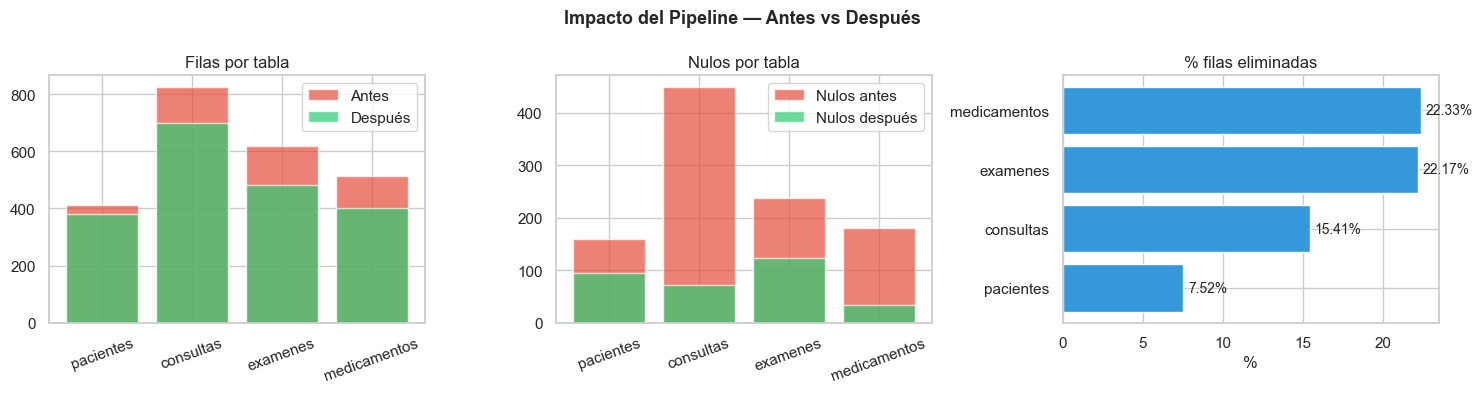

✅ Visualización guardada en data/08_reporting/


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Cargar reportes generados por el pipeline
comp = pd.read_csv('../data/08_reporting/comparacion_antes_despues.csv')
val  = pd.read_csv('../data/08_reporting/reporte_validacion.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Impacto del Pipeline — Antes vs Después', fontsize=13, fontweight='bold')

# Gráfico 1: Filas eliminadas por tabla
axes[0].bar(comp['tabla'], comp['filas_antes'], label='Antes', color='#e74c3c', alpha=0.7)
axes[0].bar(comp['tabla'], comp['filas_despues'], label='Después', color='#2ecc71', alpha=0.7)
axes[0].set_title('Filas por tabla')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=20)

# Gráfico 2: Nulos reducidos
axes[1].bar(comp['tabla'], comp['nulos_antes'], label='Nulos antes', color='#e74c3c', alpha=0.7)
axes[1].bar(comp['tabla'], comp['nulos_despues'], label='Nulos después', color='#2ecc71', alpha=0.7)
axes[1].set_title('Nulos por tabla')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=20)

# Gráfico 3: % filas eliminadas
axes[2].barh(comp['tabla'], comp['pct_eliminadas'], color='#3498db')
axes[2].set_title('% filas eliminadas')
axes[2].set_xlabel('%')
for i, v in enumerate(comp['pct_eliminadas']):
    axes[2].text(v + 0.3, i, f'{v}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/08_reporting/visualizacion_impacto_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualización guardada en data/08_reporting/")

In [20]:
# ── SECCIÓN 15 — Técnicas avanzadas de transformación (AD 1.3) ──────────────
import pandas as pd
import numpy as np

df_final = pd.read_csv('../data/03_primary/dataset_final.csv', encoding='utf-8')

# 1. VECTORIZACIÓN con NumPy broadcasting
#    Calcular z-score manual sin loop — opera sobre todo el array a la vez
costos = df_final['costo'].dropna().values
costo_zscore = (costos - costos.mean()) / costos.std()
print(f"Z-score vectorizado — min: {costo_zscore.min():.2f}, max: {costo_zscore.max():.2f}")

# 2. PIVOT TABLE — resumen por especialidad y previsión
pivot = pd.pivot_table(
    df_final,
    values='costo_total',
    index='especialidad',
    columns='prevision',
    aggfunc='mean',
    fill_value=0
).round(0)
print("\nPivot: costo promedio por especialidad y previsión:")
display(pivot)

# 3. RESHAPE con NumPy — reorganizar array numérico
arr = df_final[['costo_scaled', 'resultado_promedio', 'edad']].dropna().values
n_filas = (len(arr) // 3) * 3
arr_reshape = arr[:n_filas].reshape(-1, 3, 3)
print(f"\nReshape: array original {arr[:n_filas].shape} → {arr_reshape.shape}")

# 4. CHUNKING — procesar dataset en bloques (simula gran escala)
chunk_size = 100
resultados_chunk = []
for i in range(0, len(df_final), chunk_size):
    chunk = df_final.iloc[i:i+chunk_size]
    resultados_chunk.append(chunk['costo_total'].mean())
print(f"\nChunking: procesados {len(resultados_chunk)} bloques de {chunk_size} filas")
print(f"Promedio global calculado por chunks: {np.mean(resultados_chunk):.2f}")

# 5. GROUPBY avanzado con múltiples agregaciones simultáneas
resumen_avanzado = (
    df_final.groupby('especialidad')
    .agg(
        n_pacientes=('id_paciente', 'nunique'),
        costo_medio=('costo_total', 'mean'),
        costo_max=('costo_total', 'max'),
        edad_media=('edad', 'mean'),
        pct_con_examenes=('n_examenes', lambda x: (x > 0).mean() * 100)
    )
    .round(2)
    .sort_values('costo_medio', ascending=False)
)
print("\nGroupBy avanzado por especialidad:")
display(resumen_avanzado)

Z-score vectorizado — min: -1.90, max: 2.03

Pivot: costo promedio por especialidad y previsión:


prevision,Desconocido,Fonasa A,Fonasa B,Fonasa C,Fonasa D,Isapre,Particular
especialidad,,,,,,,
CardiologãA,0.00,0.00,500518.00,305692.00,9818.00,218932.00,0.00
Cardiologã­A,169430.00,251819.00,385932.00,231709.00,191956.00,323634.00,288146.00
DermatologãA,0.00,0.00,383688.00,231402.00,0.00,499821.00,372437.00
Dermatologã­A,198216.00,224635.00,285294.00,257779.00,217697.00,302259.00,261058.00
Desconocido,326780.00,511052.00,323941.00,318134.00,416136.00,331489.00,295989.00
GinecologãA,154456.00,128265.00,34453.00,291795.00,274112.00,0.00,0.00
Ginecologã­A,324887.00,309865.00,313683.00,270123.00,300147.00,257370.00,289897.00
Medicina General,295295.00,295368.00,354891.00,240509.00,281273.00,286524.00,254573.00
NeurologãA,0.00,474941.00,0.00,284625.00,378930.00,43732.00,0.00



Reshape: array original (663, 3) → (221, 3, 3)

Chunking: procesados 7 bloques de 100 filas
Promedio global calculado por chunks: 275595.45

GroupBy avanzado por especialidad:


,n_pacientes,costo_medio,costo_max,edad_media,pct_con_examenes
especialidad,,,,,
DermatologãA,5,343749.90,499821.00,42.72,40.00
Desconocido,26,340888.48,526732.00,50.25,33.33
TraumatologãA,5,320543.80,515573.00,40.08,0.00
NeurologãA,5,312231.40,474941.00,41.50,20.00
Ginecologã­A,78,289969.44,566421.00,56.97,52.27
Traumatologã­A,75,282749.16,525994.00,49.87,50.63
Medicina General,76,277458.86,500102.00,54.29,46.43
Pediatrã­A,73,271284.32,508752.00,49.75,44.58
Cardiologã­A,64,270047.43,542922.00,53.78,46.38
